In [46]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from pydantic import BaseModel, Field
import ast
import json
import re

In [47]:
def parse_model_json(content):
  if isinstance(content, dict):
    return content

  if not isinstance(content, str):
    return content

  content = content.strip()
  content = re.sub(r'^```(?:json)?\s*|\s*```$', '', content, flags=re.IGNORECASE | re.DOTALL).strip()
  match = re.search(r'\{.*\}', content, flags=re.DOTALL)
  if match:
    content = match.group(0)

  try:
    return json.loads(content)
  except json.JSONDecodeError:
    try:
      return ast.literal_eval(content)
    except (ValueError, SyntaxError):
      return content

In [48]:
load_dotenv()

True

In [49]:
class EssayEvaluatorState(TypedDict):
  essay: str
  clarity_of_thought: list[str]
  depth_of_analysis: list[str]
  language_quality: list[str]
  final_evaluator: list[str]

In [50]:
llm = ChatGoogleGenerativeAI(
  model="gemini-3.1-flash-lite",
)

In [51]:
class OutputSchema(BaseModel):
  feedback: str = Field(description="Detailed feedback (not too long, not too short, just in normal length)")
  score: int = Field(description="Score out of 10", ge=0, le=10)

In [52]:
model = llm.with_structured_output(OutputSchema)

In [53]:
model.invoke(f"Evaluate this essay (The Transformative Power of ReadingReading is far more than a simple pastime; it is a fundamental cognitive exercise that shapes our understanding of the world. When we open a book, we do not just consume words—we engage in an interactive process that stimulates our imagination, expands our vocabulary, and enhances our ability to think critically. Unlike passive forms of entertainment, such as watching television, reading requires active mental participation. This active engagement strengthens the neural pathways in our brains, improving our memory, focus, and overall cognitive health.Furthermore, literature serves as a profound tool for empathy and personal growth. By stepping into the shoes of different characters and exploring diverse cultures, readers are able to experience realities far removed from their own. This exposure to varying perspectives naturally fosters tolerance and a deeper understanding of the human condition. Whether delving into historical accounts, scientific theories, or fictional narratives, individuals develop a broader worldview, making them more adaptable and open-minded in their daily lives.Ultimately, the habit of reading is a lifelong investment in self-improvement and intellectual independence. It equips individuals with the communication skills necessary to articulate their thoughts clearly and persuasively. In an era dominated by rapid information and fleeting distractions, dedicating time to read allows us to slow down, reflect, and cultivate a deeper inner life. Cultivating this daily practice remains one of the most accessible and effective ways to enrich the mind and broaden one's horizons.) and give me the feedback and score")

OutputSchema(feedback='The essay is well-structured, persuasive, and maintains a clear, academic tone throughout. You effectively argued for the benefits of reading, covering cognitive development, empathy, and personal growth with coherent transitions. To improve, consider incorporating specific examples or evidence to strengthen the claims, as the current text relies heavily on generalizations. Additionally, ensure the formatting of the title is addressed to improve professional presentation.', score=9)

In [54]:
def cot_agent(state: EssayEvaluatorState):
  """Determines the clarity of thought from the given essay and topic and returns the feedback and score from 1 to 10 in JSON format."""

  essay = state['essay']

  cot_agent_prompt = f"""
    You are an expert in assessing the clarity of thought of the essay.

    Analyze the essay deeply and then give the feedback and score.

    Essay: {essay}

    You are given an essay and topic and then you give the feedback on clarity of thought of the essay.

    Also give the score on clarity of thought from 1 to 10.

    don't make mistakes.
  """

  response = model.invoke([HumanMessage(content=cot_agent_prompt)])
  cot_feedback = response.feedback
  cot_score = response.score
  cot = {
    "feedback": cot_feedback,
    "score": cot_score
  }

  return {
    "clarity_of_thought": cot
  }

In [55]:
def doa_agent(state: EssayEvaluatorState):
  """Determines the depth of analysis from the given essay and topic and returns the feedback and score from 1 to 10 in JSON format."""

  essay = state['essay']

  doa_agent_prompt = f"""
    You are an expert in assessing the depth of analysis of the essay.

    Analyze the essay deeply and then give the feedback and score.

    Essay: {essay}

    You are given an essay and then you give the feedback on depth of analysis of the essay.

    Also give the score on depth of analysis from 1 to 10.

    don't make mistakes.
  """

  response = model.invoke([HumanMessage(content=doa_agent_prompt)])
  doa_feedback = response.feedback
  doa_score = response.score
  doa = {
    "feedback": doa_feedback,
    "score": doa_score
  }

  return {
    "depth_of_analysis": doa
  }

In [56]:
def lq_agent(state: EssayEvaluatorState):
  """Determines the language quality of the given essay and topic and returns the feedback and score from 1 to 10 in JSON format."""

  essay = state['essay']

  lq_agent_prompt = f"""
    You are an expert in assessing the language quality of the essay.

    Analyze the essay deeply and then give the feedback and score.

    Essay: {essay}

    You are given an essay and then you give the feedback on language quality of the essay.

    Also give the score on language quality from 1 to 10.

    don't make mistakes.
  """

  response = model.invoke([HumanMessage(content=lq_agent_prompt)])
  lq_feedback = response.feedback
  lq_score = response.score
  lq = {
    "feedback": lq_feedback,
    "score": lq_score
  }

  return {
    "language_quality": lq
  }

In [57]:
def fianl_evaluator_agent(state: EssayEvaluatorState):
  """Determines the final feedback of the essay and returns the feedback and average score from clarity of thought score, depth of analysis score, and language quality score in JSON format."""

  essay = state['essay']
  cot = state['clarity_of_thought']
  cot_score = cot['score']
  doa = state['depth_of_analysis']
  doa_score = doa['score']
  lq = state['language_quality']
  lq_score = lq['score']

  final_evaluator_agent_prompt = f"""
    You are an expert essay evaluator. Your role is very crucial and you are the last node of the workflow.

    You have to give final feedback and average score of the essay on the basis of essay, clarity_of_thought, depth_of_analysis, and language_quality.

    Essay: {essay}
    Clarity Of Thought: {cot}
    Depth Of Analysis: {doa}
    Language Quality: {lq}

    Analyze these things / metrics deeply and then give the final feedback.

    don't make mistakes.
  """


  response = llm.invoke([HumanMessage(content=final_evaluator_agent_prompt)])
  final_evaluator_feedback = response.content[0]['text']

  scores = [cot_score, doa_score, lq_score]
  sum_scores = sum(scores)
  len_scores = len(scores)
  avg_score = sum_scores / len_scores 
  final_evaluator = {
    "feedback": final_evaluator_feedback,
    "score": avg_score
  }



  return {
    "final_evaluator": final_evaluator
  }

In [58]:
graph = StateGraph(EssayEvaluatorState)

graph.add_node('Clarity Of Thought', cot_agent)
graph.add_node('Depth Of Analysis', doa_agent)
graph.add_node('Language Quality', lq_agent)
graph.add_node('Final Evaluator', fianl_evaluator_agent)

graph.add_edge(START, "Clarity Of Thought")
graph.add_edge(START, "Depth Of Analysis")
graph.add_edge(START, "Language Quality")

graph.add_edge("Clarity Of Thought", "Final Evaluator")
graph.add_edge("Depth Of Analysis", "Final Evaluator")
graph.add_edge("Language Quality", "Final Evaluator")

graph.add_edge("Final Evaluator", END)

workflow = graph.compile()

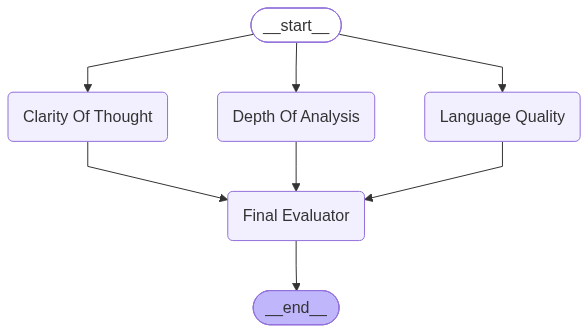

In [59]:
workflow

In [60]:
essay = f"""
# Agentic AI in Marketing and Sale

Agentic AI is new AI and many company use it now. This AI not only write thing but also doing work by ownself. It making decision and doing many job together. Before peoples do all work but now AI helping lot and company liking because save much time and money.

In marketing Agentic AI look customer what they doing and what they buying before. Then AI showing advertisment and product maybe customer like. AI also making email, social media post and other writing. If ad not working then AI changing it by itself. Human not need checking every time because AI keep looking all time.

In sales also Agentic AI doing many work. It finding customer who maybe buy product. It sending email and booking meeting and putting data in CRM. AI also hearing sale call and telling salesman what he doing wrong. So salesman not wasting much time in small work and can sell more things.

There have many good thing from Agentic AI. Company work more fast, customer getting better service and less people needed for boring work. But sometime AI make wrong answer or wrong decision because AI not human. Company need checking AI because if AI making mistake then customer maybe angry and company lose money.

In ending Agentic AI becoming very big in marketing and sale. More and more company using because it make work easy and fast. Future many business use this AI more. AI not taking every human job but it helping peoples alot for doing work more better and quick.
"""

In [61]:
result = workflow.invoke({"essay": essay})
result

{'essay': '\n# Agentic AI in Marketing and Sale\n\nAgentic AI is new AI and many company use it now. This AI not only write thing but also doing work by ownself. It making decision and doing many job together. Before peoples do all work but now AI helping lot and company liking because save much time and money.\n\nIn marketing Agentic AI look customer what they doing and what they buying before. Then AI showing advertisment and product maybe customer like. AI also making email, social media post and other writing. If ad not working then AI changing it by itself. Human not need checking every time because AI keep looking all time.\n\nIn sales also Agentic AI doing many work. It finding customer who maybe buy product. It sending email and booking meeting and putting data in CRM. AI also hearing sale call and telling salesman what he doing wrong. So salesman not wasting much time in small work and can sell more things.\n\nThere have many good thing from Agentic AI. Company work more fast,